In [ ]:
!pip install flask pyngrok tensorflow --quiet

from google.colab import files
uploaded = files.upload()

Saving All_Stocks_Data (1).csv to All_Stocks_Data (1).csv


In [ ]:
import pandas as pd
import numpy as np

# Use the uploaded filename detected in the kernel
# If multiple versions exist, we'll try the one you just uploaded
filename = 'All_Stocks_Data (1).csv'

# Load and reshape your wide-format CSV
raw = pd.read_csv(filename, header=0, index_col=1)
raw = raw.drop(columns=raw.columns[0], errors="ignore")
raw.columns = pd.to_datetime(raw.columns, errors="coerce")
raw = raw.T.sort_index()
raw = raw.apply(pd.to_numeric, errors="coerce")

# Pick a stock
TICKER = "3MINDIA"
df = raw[[TICKER]].copy()
df.columns = ["Close"]
df.dropna(inplace=True)

# Save with index named "Date" so subsequent cells read it correctly
df.index.name = "Date"
df.to_csv("stock_data.csv")

print(f"Successfully processed {filename}")
print(df.head())
print("Shivesh Prateek Sinha-2330047")

Successfully processed All_Stocks_Data (1).csv
               Close
Date                
2020-01-01  21721.95
2020-01-02  21381.15
2020-01-03  21335.85
2020-01-06  21089.70
2020-01-07  21660.40
Shivesh Prateek Sinha-2330047


In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Load data
df = pd.read_csv("stock_data.csv", index_col="Date", parse_dates=True)

# Handle missing values
df.dropna(inplace=True)

# Scale data
scaler = MinMaxScaler(feature_range=(0, 1))
df_scaled = scaler.fit_transform(df)

# Split into train & test
train_size = int(len(df_scaled) * 0.8)
train_data, test_data = df_scaled[:train_size], df_scaled[train_size:]

# Prepare datasets
X_train, y_train = np.array(range(len(train_data))), train_data.flatten()
X_test, y_test   = np.array(range(len(train_data), len(df_scaled))), test_data.flatten()

print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print("Shivesh Prateek Sinha-2330047")

Train: 365 | Test: 92
Shivesh Prateek Sinha-2330047


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Train Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train.reshape(-1, 1), y_train)

# Make Predictions
lr_predictions = lr_model.predict(X_test.reshape(-1, 1))
lr_predictions = scaler.inverse_transform(lr_predictions.reshape(-1, 1))

# Evaluate
lr_mse = mean_squared_error(scaler.inverse_transform(test_data), lr_predictions)
print(f"Linear Regression MSE: {lr_mse}")

Linear Regression MSE: 1092668.1907172343


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Function to prepare time-series dataset
def create_sequences(data, seq_length=10):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

# Prepare LSTM Data
seq_length = 10
X_train_lstm, y_train_lstm = create_sequences(train_data, seq_length)
X_test_lstm,  y_test_lstm  = create_sequences(test_data,  seq_length)

# Reshape for LSTM
X_train_lstm = np.reshape(X_train_lstm, (X_train_lstm.shape[0], X_train_lstm.shape[1], 1))
X_test_lstm  = np.reshape(X_test_lstm,  (X_test_lstm.shape[0],  X_test_lstm.shape[1],  1))

# Build LSTM Model
lstm_model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(seq_length, 1)),
    LSTM(50, return_sequences=False),
    Dense(25),
    Dense(1)
])

# Compile & Train
lstm_model.compile(optimizer="adam", loss="mean_squared_error")
lstm_model.fit(X_train_lstm, y_train_lstm, epochs=20, batch_size=16, verbose=1)

# Make Predictions
lstm_predictions = lstm_model.predict(X_test_lstm)
lstm_predictions = scaler.inverse_transform(lstm_predictions)

# Evaluate
lstm_mse = mean_squared_error(
    scaler.inverse_transform(y_test_lstm.reshape(-1, 1)),
    lstm_predictions
)
print(f"LSTM MSE: {lstm_mse}")

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0396
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0081
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0051
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0050
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0049
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0049
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0045
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0047
Epoch 9/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0042
Epoch 10/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0042
Epoch 11/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0039
Epoch 12/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0038
Epoch 13/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0042
Epoch 14/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0037
Epoch 15/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0034
Epoch 16/20
23/


========== Model Evaluation ==========
  Linear Regression MSE : 1092668.1907


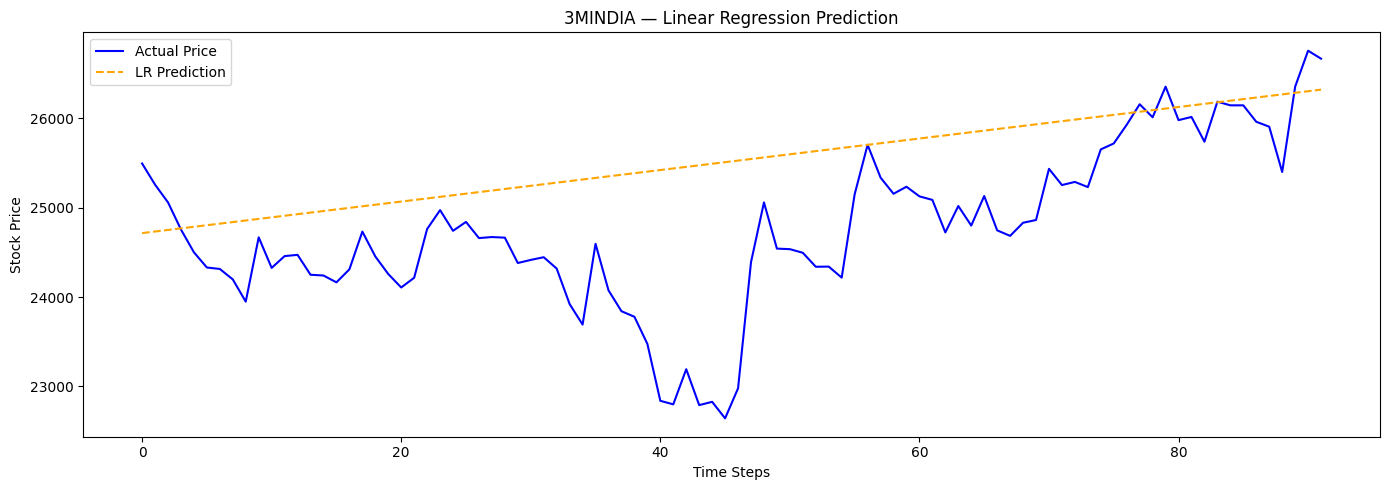

Shivesh Prateek Sinha-2330047


In [ ]:
print("\n========== Model Evaluation ==========")
print(f"  Linear Regression MSE : {lr_mse:.4f}")
print("=======================================")

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(scaler.inverse_transform(test_data), label="Actual Price", color="blue")
plt.plot(lr_predictions, label="LR Prediction", color="orange", linestyle="--")

plt.title(f"{TICKER} — Linear Regression Prediction")
plt.xlabel("Time Steps")
plt.ylabel("Stock Price")
plt.legend()
plt.tight_layout()
plt.show()
print("Shivesh Prateek Sinha-2330047")

In [ ]:
import os, threading
from flask import Flask, request, jsonify, render_template

app = Flask(__name__)

@app.route("/")
def home():
    return render_template("index.html")

@app.route("/tickers")
def tickers():
    return jsonify({"tickers": sorted(raw.columns.tolist())})

@app.route("/predict", methods=["POST"])
def predict():
    data       = request.json
    days_ahead = int(data.get("days", 1))

    future_x = np.array(range(len(df_scaled), len(df_scaled) + days_ahead)).reshape(-1, 1)
    lr_future_predictions = lr_model.predict(future_x)
    lr_future_predictions = scaler.inverse_transform(
        lr_future_predictions.reshape(-1, 1)
    ).flatten().tolist()

    # LSTM future — roll window forward one step at a time
    scaled_all = scaler.transform(df[["Close"]].values)
    window = list(scaled_all[-seq_length:].flatten())
    lstm_future_predictions = []
    for _ in range(days_ahead):
        inp = np.array(window[-seq_length:]).reshape(1, seq_length, 1)
        p   = lstm_model.predict(inp, verbose=0)[0][0]
        lstm_future_predictions.append(float(scaler.inverse_transform([[p]])[0][0]))
        window.append(p)

    return jsonify({
        "linear_regression": lr_future_predictions,
        "lstm":              lstm_future_predictions
    })

print("✅ Flask app ready")

✅ Flask app ready


In [ ]:
os.makedirs("templates", exist_ok=True)

with open("templates/index.html", "w") as f:
    f.write("""<!DOCTYPE html>
<html lang='en'>
<head>
  <meta charset='UTF-8'>
  <meta name='viewport' content='width=device-width, initial-scale=1.0'>
  <title>Stock Price Prediction</title>
  <script src='https://cdn.jsdelivr.net/npm/chart.js'></script>
  <style>
    body { font-family: Arial, sans-serif; background: #f0f2f5; padding: 2rem; }
    h2   { color: #333; }
    label, select, input, button { font-size: 1rem; margin: 4px; }
    button { padding: 6px 18px; background: #4f46e5; color: white; border: none; border-radius: 6px; cursor: pointer; }
    button:hover { background: #4338ca; }
    canvas { margin-top: 1.5rem; background: white; border-radius: 8px; padding: 1rem; }
  </style>
</head>
<body>
  <h2>Stock Price Prediction</h2>
  <label>Stock:</label>
  <select id='tickerSelect'></select>
  &nbsp;
  <label>Days to Predict:</label>
  <input type='number' id='daysInput' value='5' min='1' max='90' style='width:70px'>
  &nbsp;
  <button onclick='predictStock()'>Predict</button>
  <canvas id='stockChart'></canvas>
  <script>
    let chartInstance = null;
    async function loadTickers() {
      const res  = await fetch('/tickers');
      const data = await res.json();
      const sel  = document.getElementById('tickerSelect');
      data.tickers.forEach(t => {
        const o = document.createElement('option');
        o.value = o.text = t;
        sel.appendChild(o);
      });
      predictStock();
    }
    async function predictStock() {
      let days   = document.getElementById('daysInput').value;
      let response = await fetch('/predict', {
        method: 'POST',
        headers: { 'Content-Type': 'application/json' },
        body: JSON.stringify({ days: days })
      });
      let data        = await response.json();
      let predictions = data.linear_regression;
      let labels = [];
      for (let i = 1; i <= predictions.length; i++) {
        labels.push('Day ' + i);
      }
      if (chartInstance) chartInstance.destroy();
      chartInstance = new Chart(document.getElementById('stockChart'), {
        type: 'line',
        data: {
          labels: labels,
          datasets: [
            {
              label: 'Linear Regression Prediction',
              data: predictions,
              borderColor: 'blue',
              fill: false
            }
          ]
        }
      });
    }
    window.onload = loadTickers;
  </script>
</body>
</html>""")

print("✅ index.html updated (LSTM removed)")

from google.colab.output import eval_js
public_url = eval_js("google.colab.kernel.proxyPort(5000)")
print(f"\nဠ Open the app at this link:\n{public_url}\n")

import threading
threading.Thread(
    target=lambda: app.run(port=5000, use_reloader=False, debug=False)
).start()

✅ index.html updated (LSTM removed)

ဠ Open the app at this link:
https://5000-m-s-wp9v1lqbdnuj-c.us-east1-1.prod.colab.dev



In [ ]:
from pyngrok import ngrok
ngrok.kill()
print("All ngrok processes killed.")

All ngrok processes killed.
